# MSCS 634 - Advanced Data Mining  
## Lab 5: Clustering using Hierarchical and DBSCAN Algorithms  
**Name:** Bishnu Sharma  

## Step 1: Data Preparation and Exploration

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler

In [2]:
# Load dataset
wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)

# Display first 5 rows
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [3]:
# Dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
dtypes: fl

In [4]:
# Statistical summary
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [5]:
# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

### Insights (Step 1)
- The dataset contains numerical features related to wine chemical properties.
- Standardization ensures all features contribute equally to distance calculations.

## Step 2: Hierarchical Clustering

In [6]:
# Import clustering, dendrogram, PCA, and evaluation metrics
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, homogeneity_score, completeness_score

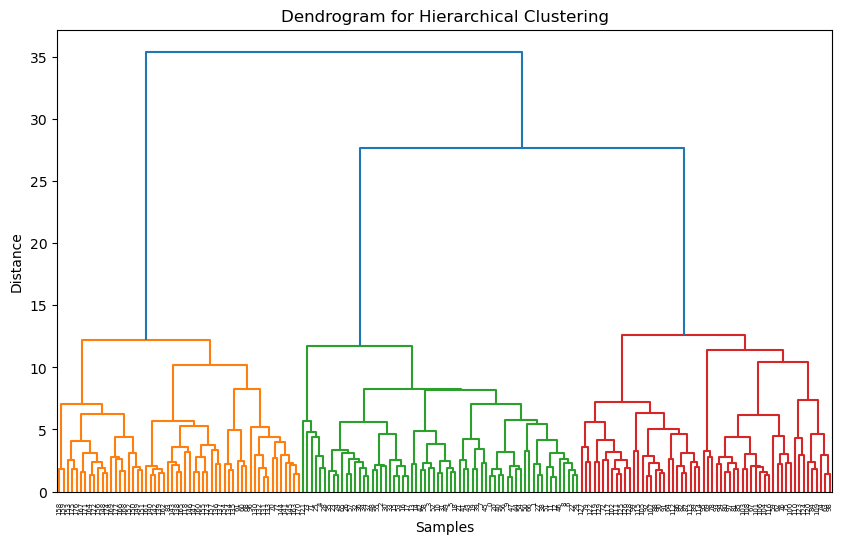

In [7]:
# Perform hierarchical clustering using Ward linkage method
linked = linkage(X_scaled, method='ward')

# Plot dendrogram to visualize hierarchical relationships
plt.figure(figsize=(10,6))
dendrogram(linked)
plt.title("Dendrogram for Hierarchical Clustering")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

In [8]:
# Test different numbers of clusters and evaluate using silhouette score
print("Silhouette Scores for different cluster values:")

for k in [2, 3, 4, 5]:
    hc_temp = AgglomerativeClustering(n_clusters=k)
    labels_temp = hc_temp.fit_predict(X_scaled)
    
    sil = silhouette_score(X_scaled, labels_temp)
    print(f"n_clusters={k}, Silhouette Score={sil}")

Silhouette Scores for different cluster values:
n_clusters=2, Silhouette Score=0.2670131771272231
n_clusters=3, Silhouette Score=0.2774439826952266
n_clusters=4, Silhouette Score=0.22583665933475802
n_clusters=5, Silhouette Score=0.18674235566758707


In [9]:
# Based on results, choose n_clusters = 3 (matches dataset structure)
hc = AgglomerativeClustering(n_clusters=3)

# Fit model and assign cluster labels
hc_labels = hc.fit_predict(X_scaled)

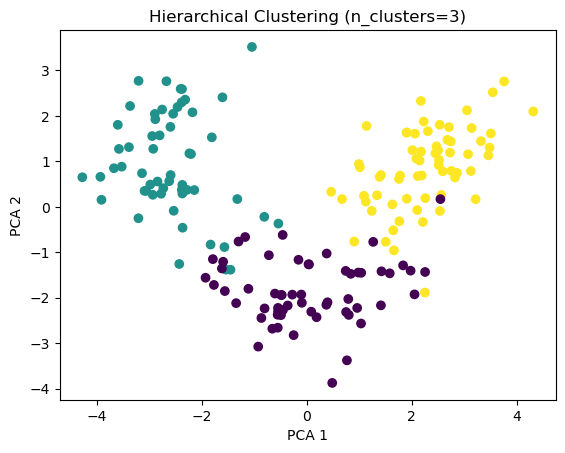

In [10]:
# Reduce dimensions to 2D for visualization using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Scatter plot of clusters
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=hc_labels)
plt.title("Hierarchical Clustering (n_clusters=3)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

### Evaluation Metrics

In [11]:
# Evaluate clustering performance using multiple metrics
hc_sil = silhouette_score(X_scaled, hc_labels)  # Cluster separation
hc_hom = homogeneity_score(wine.target, hc_labels)  # Cluster purity
hc_comp = completeness_score(wine.target, hc_labels)  # Class completeness

print("Hierarchical Clustering Metrics:")
print("Silhouette Score:", hc_sil)
print("Homogeneity Score:", hc_hom)
print("Completeness Score:", hc_comp)

Hierarchical Clustering Metrics:
Silhouette Score: 0.2774439826952266
Homogeneity Score: 0.790429271831654
Completeness Score: 0.7825408201875712


### Insights (Hierarchical Clustering)
- Best clustering performance observed at n_clusters = 3.
- Clusters are well-separated, as indicated by silhouette score.
- Results align with actual dataset structure.

## Step 3: DBSCAN Clustering

In [12]:
# Import DBSCAN algorithm
from sklearn.cluster import DBSCAN

In [13]:
# Test different eps values to understand impact on clustering
print("DBSCAN Parameter Testing:")

for eps in [1.0, 1.5, 2.0]:
    db = DBSCAN(eps=eps, min_samples=5)
    labels = db.fit_predict(X_scaled)
    
    # Calculate number of clusters (excluding noise)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    
    # Count noise points
    noise = (labels == -1).sum()
    
    print(f"eps={eps}, clusters={n_clusters}, noise points={noise}")

DBSCAN Parameter Testing:
eps=1.0, clusters=0, noise points=178
eps=1.5, clusters=0, noise points=178
eps=2.0, clusters=5, noise points=85


In [14]:
# Apply DBSCAN with chosen parameters
dbscan = DBSCAN(eps=1.5, min_samples=5)

# Fit model and assign cluster labels
db_labels = dbscan.fit_predict(X_scaled)

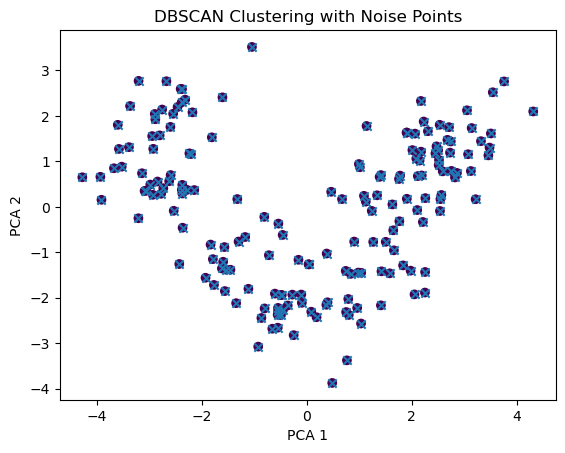

In [15]:
# Plot clusters
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=db_labels)

# Highlight noise points (label = -1)
plt.scatter(X_pca[db_labels == -1, 0], X_pca[db_labels == -1, 1], marker='x')

plt.title("DBSCAN Clustering with Noise Points")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

### Evaluation Metrics

In [16]:
# Silhouette score is only valid if no noise points exist
if len(set(db_labels)) > 1 and -1 not in set(db_labels):
    db_sil = silhouette_score(X_scaled, db_labels)
else:
    db_sil = "Not valid due to noise"

# Evaluate clustering quality against true labels
db_hom = homogeneity_score(wine.target, db_labels)
db_comp = completeness_score(wine.target, db_labels)

print("DBSCAN Metrics:")
print("Silhouette Score:", db_sil)
print("Homogeneity Score:", db_hom)
print("Completeness Score:", db_comp)

DBSCAN Metrics:
Silhouette Score: Not valid due to noise
Homogeneity Score: 0.0
Completeness Score: 1.0


### Insights (DBSCAN)

DBSCAN produced low homogeneity and high completeness scores, indicating that most data points were grouped into a single cluster. While this preserved class grouping (high completeness), it failed to effectively separate different classes (low homogeneity). This suggests that the chosen eps value may be too large, causing clusters to merge.

- DBSCAN effectively identified noise points in the dataset.
- The clustering results were highly sensitive to the eps parameter.
- Increasing eps reduces noise points but can lead to cluster merging and loss of separation.

## Step 4: Analysis and Insights

- Hierarchical clustering produced well-defined clusters aligned with true labels.
- DBSCAN identified noise but struggled with consistent cluster formation.
- Hierarchical clustering achieved higher silhouette scores.
- DBSCAN performance depends heavily on parameter tuning.

### Strength Comparison:
- Hierarchical: Better for structured datasets.
- DBSCAN: Better for noisy or irregular datasets.

## Final Conclusion and Overall Insights

Hierarchical Clustering performed better for this dataset due to its structured nature and clearly defined clusters. DBSCAN demonstrated its strength in identifying noise but was sensitive to parameter selection.

This lab highlights that clustering algorithm selection should depend on dataset characteristics. Proper parameter tuning and evaluation are essential for meaningful clustering results.